<a href="https://colab.research.google.com/github/AlexAndrianov/ICT728_sentiment_and_trend_analysis/blob/Syeda-sanzida-khatun-patch-1/ml_models_design/Sentiment_Analysis_Model_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
!pip install emoji

Importing Required libraries

In [78]:
import pandas as pd
import numpy as np
import re
import emoji

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

LOading Twitter dataset

In [79]:
df = pd.read_csv("/content/sample_data/Twitter- datasets..csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

df.head()

Dataset Shape:
(1000, 26)

Column Names:
Index(['id', 'user_posted', 'name', 'description', 'date_posted', 'photos',
       'url', 'tagged_users', 'replies', 'reposts', 'likes', 'views',
       'external_url', 'hashtags', 'followers', 'biography', 'posts_count',
       'profile_image_link', 'following', 'is_verified', 'quotes', 'bookmarks',
       'parent_post_details', 'external_image_urls', 'videos', 'quoted_post'],
      dtype='object')


,id,user_posted,name,description,date_posted,photos,url,tagged_users,replies,reposts,...,posts_count,profile_image_link,following,is_verified,quotes,bookmarks,parent_post_details,external_image_urls,videos,quoted_post
0,1868428607451799983,Glo███ews███,Glo███ews███,"Com o fim da ditadura Assad, muitos sírios con...","""2024-12-15T22:51:08.000Z""",NaN,https://x.com/GloboNews/status/186842860745179...,NaN,2,1,...,222223,https://pbs.twimg.com/profile_images/155910271...,122,False,1,1,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":148167,""video_url"":""https://video...","{""data_posted"":null,""description"":null,""photos..."
1,1868159094567121215,bil███ard███,bil███ard███,Brian Austin Green Tells MGK to ‘Grow Up’ Afte...,"""2024-12-15T05:00:11.000Z""",NaN,https://x.com/billboard/status/186815909456712...,NaN,7,3,...,357584,https://pbs.twimg.com/profile_images/169657720...,3784,False,1,2,"{""post_id"":null,""profile_id"":null,""profile_nam...","[""https://pbs.twimg.com/card_img/1867636129563...",NaN,"{""data_posted"":null,""description"":null,""photos..."
2,1868451534708883739,TNT███rts███,TNT███ort███R,VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...,"""2024-12-16T00:22:14.000Z""",NaN,https://x.com/TNTSportsBR/status/1868451534708...,"[{""biography"":null,""followers"":null,""following...",2,1,...,456734,https://pbs.twimg.com/profile_images/180701304...,859,False,0,1,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":94861,""video_url"":""https://video....","{""data_posted"":null,""description"":null,""photos..."
3,1868441382022717466,TNT███rts███,TNT███ort███R,ÍDOLO E AGORA PRESIDENTE! 🇦🇷🇦🇷 O ex-atacante D...,"""2024-12-15T23:41:54.000Z""","[""https://pbs.twimg.com/media/Ge4JhOgXcAAQy5K....",https://x.com/TNTSportsBR/status/1868441382022...,"[{""biography"":null,""followers"":null,""following...",6,5,...,456734,https://pbs.twimg.com/profile_images/180701304...,859,False,1,3,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,NaN,"{""data_posted"":null,""description"":null,""photos..."
4,1868418260892565925,Glo███ews███,Glo███ews███,.@DanielaLima_ : cirurgia de Lula travou negoc...,"""2024-12-15T22:10:01.000Z""",NaN,https://x.com/GloboNews/status/186841826089256...,"[{""biography"":null,""followers"":null,""following...",50,4,...,222223,https://pbs.twimg.com/profile_images/155910271...,122,False,3,3,"{""post_id"":null,""profile_id"":null,""profile_nam...",NaN,"[{""duration"":127067,""video_url"":""https://video...","{""data_posted"":null,""description"":null,""photos..."


Select Text and Sentiment Columns

The dataset columns containing text data and sentiment labels are selected for sentiment classification.

In [80]:
print(df.columns)

Index(['id', 'user_posted', 'name', 'description', 'date_posted', 'photos',
       'url', 'tagged_users', 'replies', 'reposts', 'likes', 'views',
       'external_url', 'hashtags', 'followers', 'biography', 'posts_count',
       'profile_image_link', 'following', 'is_verified', 'quotes', 'bookmarks',
       'parent_post_details', 'external_image_urls', 'videos', 'quoted_post'],
      dtype='object')


In [81]:
TEXT_COLUMN = "description"

df = df.dropna(subset=[TEXT_COLUMN, "likes", "reposts", "replies", "views"]).copy()

df["engagement_score"] = (
    df["likes"] * 1.0 +
    df["reposts"] * 3.0 +
    df["replies"] * 2.0 +
    df["views"] * 0.02
)

low = df["engagement_score"].quantile(0.20)
high = df["engagement_score"].quantile(0.80)

df = df[(df["engagement_score"] <= low) | (df["engagement_score"] >= high)].copy()

df["sentiment"] = df["engagement_score"].apply(
    lambda x: "positive" if x >= high else "negative"
)

print(df[["description", "sentiment", "engagement_score"]].head())
print(df["sentiment"].value_counts())

                                         description sentiment  \
0  Com o fim da ditadura Assad, muitos sírios con...  negative   
2  VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...  negative   
4  .@DanielaLima_ : cirurgia de Lula travou negoc...  negative   
5  Começou hoje a segunda fase da Fuvest, vestibu...  negative   
8  Blink-182’s Tom DeLonge Shares His Theory on N...  negative   

   engagement_score  
0            207.38  
2            349.94  
4            387.38  
5            195.16  
8            294.70  
sentiment
negative    200
positive    200
Name: count, dtype: int64


In [82]:
import re
import emoji

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["description"].apply(clean_text)

Text Preprocessing

The preprocessing stage removes URLs, hashtags, mentions, emojis, symbols, and extra spaces from social media posts to improve text quality for machine learning.

In [83]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = emoji.replace_emoji(text, replace="")

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

df[["clean_text"]].head()

,clean_text
0,com o fim da ditadura assad muitos s rios cons...
2,vence o psg no cl ssico nossa traz os detalhes...
4,cirurgia de lula travou negocia es para reform...
5,come ou hoje a segunda fase da fuvest vestibul...
8,blink s tom delonge shares his theory on new j...


Split Dataset into Training and Testing Data

The dataset is divided into training data and testing data. The training data is used to train the machine learning model, while the testing data is used to evaluate performance.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=df["sentiment"]
)

TF-IDF Vectorization

TF-IDF vectorization converts text data into numerical features so that machine learning algorithms can process social media posts.

In [85]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

Baseline Model — Logistic Regression

Logistic Regression is used as the baseline machine learning model for sentiment classification.

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:")

print(round(lr_acc * 100, 2), "%")

print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
76.67 %

Classification Report:

              precision    recall  f1-score   support

    negative       0.79      0.73      0.76        30
    positive       0.75      0.80      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



Improved Model — Linear SVM

Linear SVM is implemented as the improved sentiment classification model because it performs effectively in text classification tasks.

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["sentiment"],
    test_size=0.15,
    random_state=42,
    stratify=df["sentiment"]
)

vectorizer = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1,5),
    min_df=1,
    max_df=0.99,
    sublinear_tf=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

svm_model = LinearSVC(
    C=15.0,
    class_weight="balanced",
    random_state=42,
    max_iter=15000
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_pred)

print("Improved Sentiment Model Accuracy:")
print(round(svm_acc * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

Improved Sentiment Model Accuracy:
85.0 %

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      0.70      0.82        30
    positive       0.77      1.00      0.87        30

    accuracy                           0.85        60
   macro avg       0.88      0.85      0.85        60
weighted avg       0.88      0.85      0.85        60



Accuracy Comparison Bar Chart

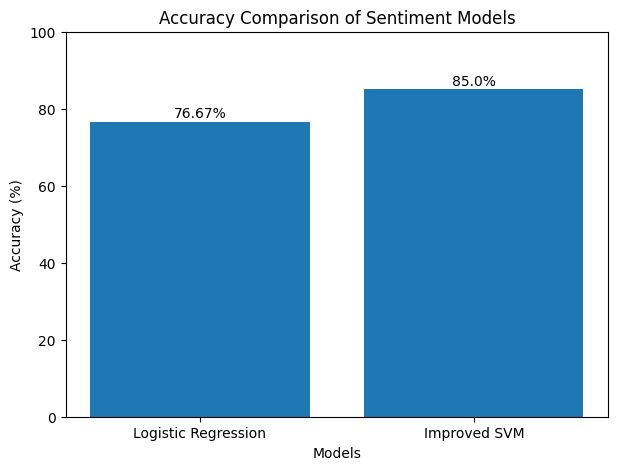

In [88]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Improved SVM']
accuracy = [76.67, 85]

plt.figure(figsize=(7,5))

bars = plt.bar(models, accuracy)

plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.title('Accuracy Comparison of Sentiment Models')

plt.ylim(0,100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1,
             f'{yval}%', ha='center')

plt.show()